# Capítulo 12 · Cómo ve una computadora una imagen

Nosotros vemos formas, colores y objetos. Una computadora recibe números organizados en una estructura. En este cuaderno construiremos imágenes pequeñas para poder observar simultáneamente esas dos caras: la representación visual y los valores que la producen.

Trabajaremos con imágenes en escala de grises y RGB, inspeccionaremos píxeles y canales, normalizaremos intensidades y formaremos un lote. Finalmente aplanaremos una imagen para comprobar qué se conserva y qué deja de quedar explícito.

## Objetivos del capítulo

Al finalizar este recorrido podrás:

- interpretar una imagen en escala de grises como una matriz de intensidades;
- relacionar filas y columnas con posiciones de píxeles;
- explicar las formas `(H, W)`, `(H, W, C)` y `(N, H, W, C)`;
- separar y visualizar los canales rojo, verde y azul;
- normalizar valores desde `[0, 255]` hasta `[0, 1]`;
- reconocer escalares, vectores, matrices e imágenes como tensores de distinto rango;
- aplanar una imagen y reconstruirla sin perder sus valores;
- estimar la cantidad de parámetros de una capa densa conectada a píxeles;
- explicar por qué la posición y la estructura espacial importan.

## Importación de librerías

Usaremos NumPy para crear y transformar los datos, Pandas para presentar algunas comparaciones, Matplotlib para convertir matrices en imágenes y TensorFlow únicamente para comprobar la forma de un tensor. No entrenaremos ningún modelo en este capítulo.

In [1]:
import os

# Reduce mensajes técnicos que no forman parte de la práctica.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.4f}".format

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.21.0


## 1. Una imagen en escala de grises

Cada posición de una imagen en escala de grises contiene una intensidad. En la convención que utilizaremos, 0 representa negro, 255 representa blanco y los valores intermedios producen grises.

La siguiente matriz de $7\times7$ contiene una figura clara sobre un fondo oscuro. El tipo `uint8` permite almacenar enteros sin signo entre 0 y 255.

In [2]:
imagen_gris = np.array([
    [0, 0, 0, 40, 0, 0, 0],
    [0, 0, 80, 160, 80, 0, 0],
    [0, 50, 170, 230, 170, 50, 0],
    [0, 140, 220, 255, 220, 140, 0],
    [0, 50, 170, 230, 170, 50, 0],
    [0, 0, 80, 160, 80, 0, 0],
    [0, 0, 0, 40, 0, 0, 0],
], dtype=np.uint8)

print("Forma:", imagen_gris.shape)
print("Dimensiones:", imagen_gris.ndim)
print("Tipo de dato:", imagen_gris.dtype)
display(pd.DataFrame(imagen_gris))

Forma: (7, 7)
Dimensiones: 2
Tipo de dato: uint8


,0,1,2,3,4,5,6
0,0,0,0,40,0,0,0
1,0,0,80,160,80,0,0
2,0,50,170,230,170,50,0
3,0,140,220,255,220,140,0
4,0,50,170,230,170,50,0
5,0,0,80,160,80,0,0
6,0,0,0,40,0,0,0


El píxel en la fila 2 y la columna 3 tiene intensidad 230.


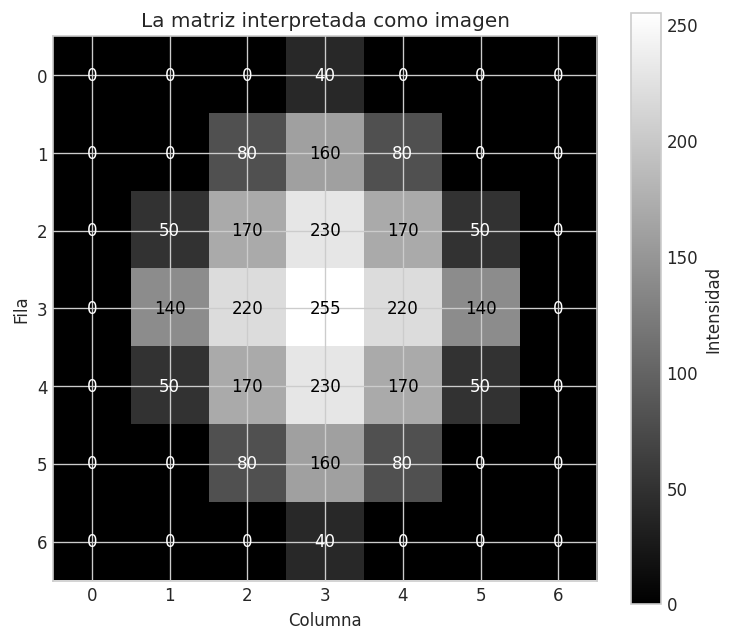

In [3]:
fig, ax = plt.subplots(figsize=(6.3, 5.5))
imagen_mostrada = ax.imshow(
    imagen_gris,
    cmap="gray",
    vmin=0,
    vmax=255,
    interpolation="nearest",
)

for fila in range(imagen_gris.shape[0]):
    for columna in range(imagen_gris.shape[1]):
        valor = imagen_gris[fila, columna]
        color_texto = "black" if valor >= 140 else "white"
        ax.text(columna, fila, str(valor), ha="center", va="center", color=color_texto)

ax.set_title("La matriz interpretada como imagen")
ax.set_xlabel("Columna")
ax.set_ylabel("Fila")
ax.set_xticks(range(imagen_gris.shape[1]))
ax.set_yticks(range(imagen_gris.shape[0]))
fig.colorbar(imagen_mostrada, ax=ax, label="Intensidad")
plt.tight_layout()
plt.show()

fila, columna = 2, 3
print(
    f"El píxel en la fila {fila} y la columna {columna} "
    f"tiene intensidad {imagen_gris[fila, columna]}."
)

La matriz y la imagen contienen exactamente la misma información. `imshow()` no descubre una figura nueva: asigna una intensidad visible a cada número.

La forma `(7, 7)` indica siete filas y siete columnas. Como se trata de escala de grises, basta un valor por posición y el array tiene dos dimensiones.

## 2. La posición también contiene información

Desplazaremos la figura una columna hacia la derecha. Las intensidades serán las mismas, pero ocuparán otras posiciones. De esta manera podremos separar dos ideas: **qué valores existen** y **dónde están ubicados**.

,Imagen,Suma de intensidades,Píxeles no negros,Intensidad máxima
0,Original,3035,23,255
1,Desplazada,3035,23,255


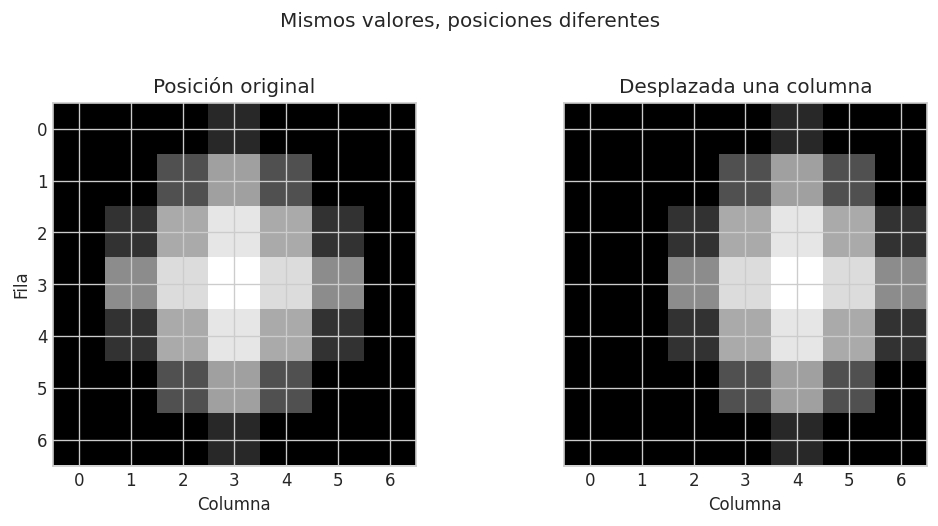

In [4]:
imagen_desplazada = np.roll(imagen_gris, shift=1, axis=1)

comparacion_posicion = pd.DataFrame({
    "Imagen": ["Original", "Desplazada"],
    "Suma de intensidades": [imagen_gris.sum(), imagen_desplazada.sum()],
    "Píxeles no negros": [
        np.count_nonzero(imagen_gris),
        np.count_nonzero(imagen_desplazada),
    ],
    "Intensidad máxima": [imagen_gris.max(), imagen_desplazada.max()],
})
display(comparacion_posicion)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2), sharex=True, sharey=True)

for ax, imagen, titulo in zip(
    axes,
    [imagen_gris, imagen_desplazada],
    ["Posición original", "Desplazada una columna"],
):
    ax.imshow(imagen, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    ax.set_title(titulo)
    ax.set_xlabel("Columna")
    ax.set_xticks(range(7))
    ax.set_yticks(range(7))

axes[0].set_ylabel("Fila")
fig.suptitle("Mismos valores, posiciones diferentes", y=1.02)
plt.tight_layout()
plt.show()

La suma, la cantidad de píxeles claros y la intensidad máxima coinciden. Sin embargo, la figura no está en el mismo lugar. Contar intensidades no alcanza para describir una imagen: también importan sus relaciones espaciales.

Aquí usamos `np.roll()` porque los bordes de la matriz son negros. Así, el desplazamiento conserva todos los valores sin introducir una zona clara por el borde opuesto.

## 3. Normalizar no cambia la apariencia

Dividiremos cada intensidad por 255. El intervalo original $[0,255]$ se convertirá en $[0,1]$:

$$
x_{\text{normalizado}}=\frac{x}{255}
$$

Los valores cambian de escala, pero mantienen sus proporciones.

Rango original: 0 a 255
Rango normalizado: 0.000 a 1.000


,Valor original,Valor normalizado
0,0,0.0000
1,40,0.1569
2,128,0.5020
3,230,0.9020
4,255,1.0000


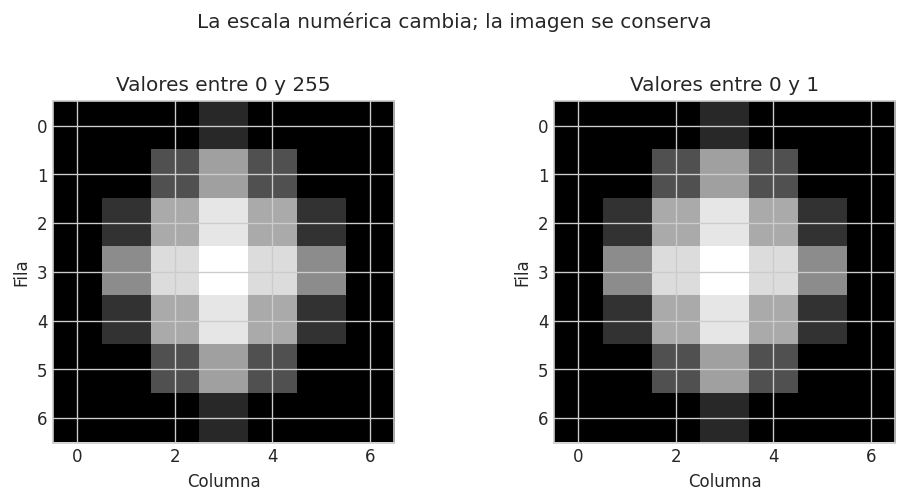

In [5]:
imagen_normalizada = imagen_gris.astype("float32") / 255.0

ejemplos_normalizacion = pd.DataFrame({
    "Valor original": [0, 40, 128, 230, 255],
})
ejemplos_normalizacion["Valor normalizado"] = (
    ejemplos_normalizacion["Valor original"] / 255.0
)
display(ejemplos_normalizacion)

print("Rango original:", imagen_gris.min(), "a", imagen_gris.max())
print(
    "Rango normalizado:",
    f"{imagen_normalizada.min():.3f}",
    "a",
    f"{imagen_normalizada.max():.3f}",
)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 4))
axes[0].imshow(imagen_gris, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
axes[0].set_title("Valores entre 0 y 255")
axes[1].imshow(imagen_normalizada, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
axes[1].set_title("Valores entre 0 y 1")

for ax in axes:
    ax.set_xlabel("Columna")
    ax.set_ylabel("Fila")

fig.suptitle("La escala numérica cambia; la imagen se conserva", y=1.02)
plt.tight_layout()
plt.show()

La intensidad 128 se transforma aproximadamente en 0,502 y 255 en 1. Las dos visualizaciones se ven iguales porque Matplotlib utiliza en cada caso el rango indicado.

La normalización no agrega ni elimina píxeles. Solo cambia la escala numérica con la que trabajará el modelo.

## 4. Una imagen RGB tiene tres canales

En RGB cada píxel contiene tres intensidades: rojo, verde y azul. Crearemos una imagen de 6 filas y 9 columnas con regiones de distintos colores. Su forma será `(6, 9, 3)`.

In [6]:
imagen_rgb = np.zeros((6, 9, 3), dtype=np.uint8)
imagen_rgb[:, 0:3] = [230, 50, 50]       # zona rojiza
imagen_rgb[:, 3:6] = [50, 210, 80]       # zona verdosa
imagen_rgb[:, 6:9] = [50, 100, 235]      # zona azulada
imagen_rgb[0:2, 3:6] = [255, 255, 255]   # zona blanca
imagen_rgb[2:4, 2:7] = [255, 180, 40]    # franja anaranjada

posiciones = [(4, 1), (1, 4), (3, 4), (4, 7)]
muestras_rgb = pd.DataFrame([
    {
        "Fila": fila,
        "Columna": columna,
        "R": int(imagen_rgb[fila, columna, 0]),
        "G": int(imagen_rgb[fila, columna, 1]),
        "B": int(imagen_rgb[fila, columna, 2]),
    }
    for fila, columna in posiciones
])

print("Forma:", imagen_rgb.shape)
print("Dimensiones:", imagen_rgb.ndim)
print("Cantidad de valores:", imagen_rgb.size)
display(muestras_rgb)

Forma: (6, 9, 3)
Dimensiones: 3
Cantidad de valores: 162


,Fila,Columna,R,G,B
0,4,1,230,50,50
1,1,4,255,255,255
2,3,4,255,180,40
3,4,7,50,100,235


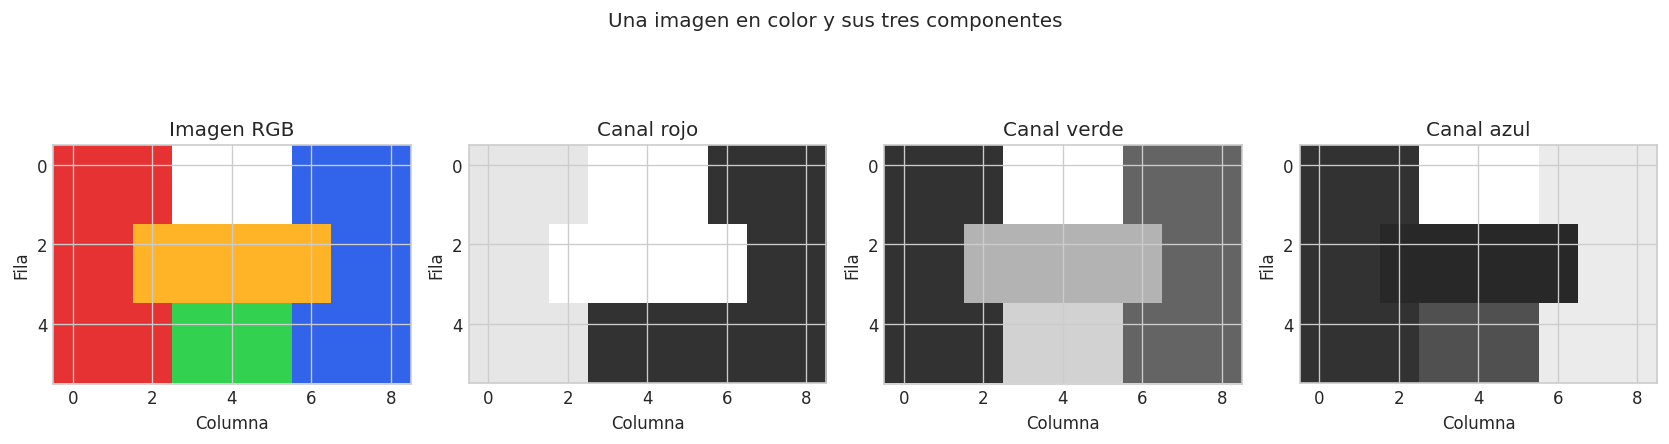

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))

axes[0].imshow(imagen_rgb, interpolation="nearest")
axes[0].set_title("Imagen RGB")

nombres_canales = ["Canal rojo", "Canal verde", "Canal azul"]
for indice, nombre in enumerate(nombres_canales):
    axes[indice + 1].imshow(
        imagen_rgb[:, :, indice],
        cmap="gray",
        vmin=0,
        vmax=255,
        interpolation="nearest",
    )
    axes[indice + 1].set_title(nombre)

for ax in axes:
    ax.set_xlabel("Columna")
    ax.set_ylabel("Fila")
    ax.set_xticks(range(0, 9, 2))
    ax.set_yticks(range(0, 6, 2))

fig.suptitle("Una imagen en color y sus tres componentes", y=1.04)
plt.tight_layout()
plt.show()

Cada canal aparece como una matriz independiente: cuanto más clara se ve una región, mayor es la intensidad de ese componente. La franja anaranjada, por ejemplo, combina mucho rojo, una cantidad intermedia de verde y poco azul.

La forma `(6, 9, 3)` se interpreta como altura, ancho y canales: $H	imes W	imes C$.

In [8]:
imagen_rgb_normalizada = imagen_rgb.astype("float32") / 255.0

pixel_original = np.array([255, 128, 0], dtype=np.uint8)
pixel_normalizado = pixel_original.astype("float32") / 255.0

comparacion_pixel = pd.DataFrame({
    "Canal": ["R", "G", "B"],
    "Original": pixel_original,
    "Normalizado": pixel_normalizado,
})
display(comparacion_pixel)

print("Forma conservada:", imagen_rgb_normalizada.shape)
print("Tipo después de normalizar:", imagen_rgb_normalizada.dtype)

Forma conservada: (6, 9, 3)
Tipo después de normalizar: float32


,Canal,Original,Normalizado
0,R,255,1.0000
1,G,128,0.5020
2,B,0,0.0000


La normalización se aplica a los tres canales por igual. El píxel `[255, 128, 0]` pasa aproximadamente a `[1, 0.502, 0]`: conserva la relación entre rojo, verde y azul, pero utiliza una escala menor.

## 5. De un array a un tensor y a un lote

El rango indica cuántos ejes necesita una estructura. Un escalar tiene rango 0; un vector, rango 1; una matriz, rango 2; y una imagen RGB, rango 3.

Al reunir varias imágenes aparece un eje adicional al comienzo. Formaremos un lote de tres imágenes RGB y lo convertiremos en un tensor de TensorFlow.

In [9]:
imagen_mas_oscura = (imagen_rgb.astype("float32") * 0.55).astype(np.uint8)
imagen_reflejada = np.flip(imagen_rgb, axis=1).copy()
lote_rgb = np.stack([imagen_rgb, imagen_mas_oscura, imagen_reflejada])
tensor_lote = tf.convert_to_tensor(lote_rgb)

estructuras = [
    ("Escalar", np.array(5)),
    ("Vector", np.array([2, 4, 7])),
    ("Matriz", np.array([[1, 2], [3, 4]])),
    ("Imagen gris", imagen_gris),
    ("Imagen RGB", imagen_rgb),
    ("Lote RGB", lote_rgb),
]

tabla_tensores = pd.DataFrame({
    "Estructura": [nombre for nombre, _ in estructuras],
    "Rango": [array.ndim for _, array in estructuras],
    "Forma": [str(array.shape) for _, array in estructuras],
    "Cantidad de valores": [array.size for _, array in estructuras],
})
display(tabla_tensores)

print("Tipo del objeto:", type(tensor_lote).__name__)
print("Forma del tensor:", tensor_lote.shape)
print("Rango del tensor:", tensor_lote.ndim)

Tipo del objeto: EagerTensor
Forma del tensor: (3, 6, 9, 3)
Rango del tensor: 4


,Estructura,Rango,Forma,Cantidad de valores
0,Escalar,0,(),1
1,Vector,1,"(3,)",3
2,Matriz,2,"(2, 2)",4
3,Imagen gris,2,"(7, 7)",49
4,Imagen RGB,3,"(6, 9, 3)",162
5,Lote RGB,4,"(3, 6, 9, 3)",486


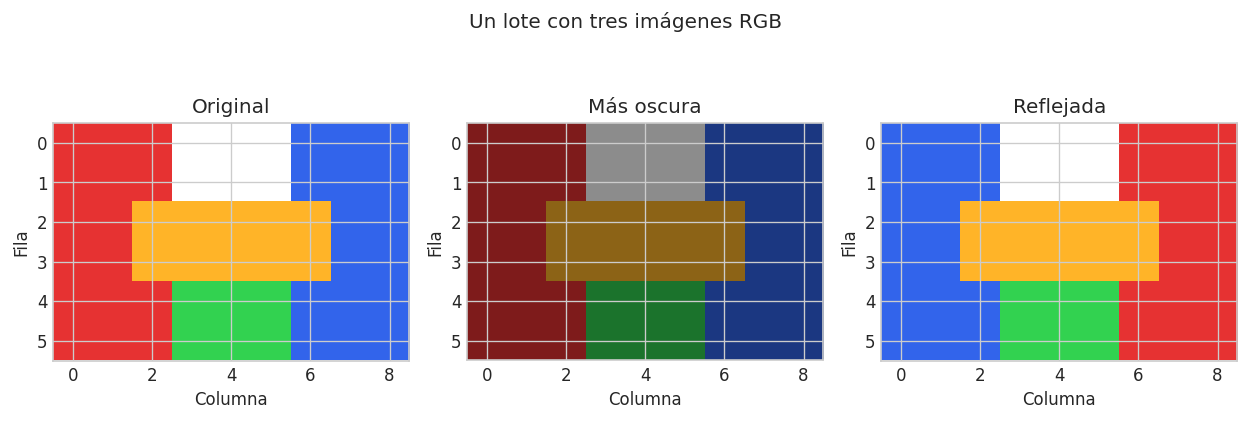

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.3))
nombres_lote = ["Original", "Más oscura", "Reflejada"]

for ax, imagen, nombre in zip(axes, lote_rgb, nombres_lote):
    ax.imshow(imagen, interpolation="nearest")
    ax.set_title(nombre)
    ax.set_xlabel("Columna")
    ax.set_ylabel("Fila")

fig.suptitle("Un lote con tres imágenes RGB", y=1.03)
plt.tight_layout()
plt.show()

El lote tiene forma `(3, 6, 9, 3)`: tres imágenes, seis filas, nueve columnas y tres canales. En notación general, corresponde a $N	imes H	imes W	imes C$.

Convertir el array en un `Tensor` no cambia los valores ni su organización. El término tensor describe una estructura numérica con una cantidad determinada de ejes.

## 6. Aplanar una imagen

Una capa densa recibe una secuencia de valores. El aplanamiento reorganiza una matriz como un vector: una imagen de $7	imes7$ pasará de la forma `(7, 7)` a `(49,)`.

Comprobaremos que `reshape()` permite hacer el recorrido de ida y vuelta sin modificar ningún píxel.

In [11]:
vector_gris = imagen_gris.reshape(-1)
imagen_reconstruida = vector_gris.reshape(imagen_gris.shape)
aplanador_keras = tf.keras.layers.Flatten()
vector_keras = aplanador_keras(imagen_gris[np.newaxis, ...])

print("Forma original:", imagen_gris.shape)
print("Forma aplanada:", vector_gris.shape)
print("Primeros 14 valores:", vector_gris[:14])
print(
    "¿La reconstrucción coincide píxel por píxel?",
    np.array_equal(imagen_gris, imagen_reconstruida),
)
print("Forma producida por Flatten para un lote de una imagen:", vector_keras.shape)

Forma original: (7, 7)
Forma aplanada: (49,)
Primeros 14 valores: [  0   0   0  40   0   0   0   0   0  80 160  80   0   0]
¿La reconstrucción coincide píxel por píxel? True
Forma producida por Flatten para un lote de una imagen: (1, 49)


El vector conserva los 49 valores y permite reconstruir la matriz original. `Flatten` no elimina intensidades.

NumPy produce el vector `(49,)`. La capa `Flatten` de Keras conserva además la dimensión del lote, por eso una imagen presentada como un lote de tamaño 1 produce `(1, 49)`.

Lo que deja de quedar explícito es la organización bidimensional: al mirar la secuencia ya no vemos que cada grupo de siete valores formaba una fila ni qué píxeles eran vecinos verticales.

## 7. Aplanamiento y cantidad de parámetros

Si conectamos todos los píxeles a todas las neuronas de una capa densa, cada conexión necesita un peso y cada neurona agrega un bias. Calcularemos dos ejemplos del capítulo.

In [12]:
casos_densos = pd.DataFrame({
    "Entrada": ["28 × 28 gris", "64 × 64 × 3 RGB"],
    "Valores de entrada": [28 * 28, 64 * 64 * 3],
    "Neuronas densas": [128, 128],
})

casos_densos["Pesos"] = (
    casos_densos["Valores de entrada"] * casos_densos["Neuronas densas"]
)
casos_densos["Bias"] = casos_densos["Neuronas densas"]
casos_densos["Parámetros totales"] = casos_densos["Pesos"] + casos_densos["Bias"]

display(casos_densos)

,Entrada,Valores de entrada,Neuronas densas,Pesos,Bias,Parámetros totales
0,28 × 28 gris,784,128,100352,128,100480
1,64 × 64 × 3 RGB,12288,128,1572864,128,1572992


La entrada de 28 × 28 conectada a 128 neuronas requiere 100.480 parámetros. Para una imagen RGB de 64 × 64, la primera capa ya supera 1,57 millones.

Esto no significa que `Flatten` sea incorrecto. Será un punto de partida útil en el próximo capítulo. La comparación muestra por qué el costo crece rápidamente cuando aumenta la resolución.

## 8. Los valores no bastan: importa su organización

Ahora desordenaremos los píxeles de la imagen. La nueva matriz contendrá exactamente las mismas intensidades y el mismo histograma, pero perderá la forma original.

¿Contienen las mismas intensidades? True
Suma original: 3035
Suma barajada: 3035


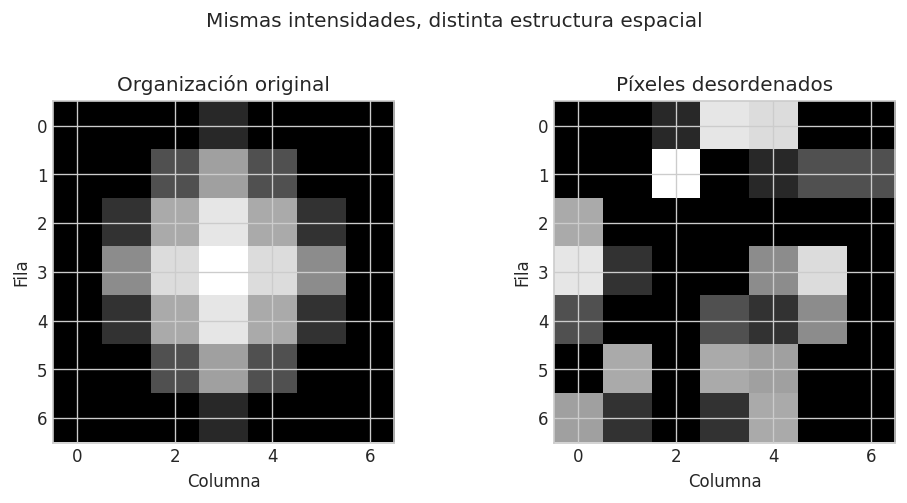

In [13]:
generador = np.random.default_rng(12)
vector_barajado = generador.permutation(vector_gris)
imagen_barajada = vector_barajado.reshape(imagen_gris.shape)

print(
    "¿Contienen las mismas intensidades?",
    np.array_equal(np.sort(vector_gris), np.sort(vector_barajado)),
)
print("Suma original:", imagen_gris.sum())
print("Suma barajada:", imagen_barajada.sum())

fig, axes = plt.subplots(1, 2, figsize=(8.5, 4))
axes[0].imshow(imagen_gris, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
axes[0].set_title("Organización original")
axes[1].imshow(imagen_barajada, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
axes[1].set_title("Píxeles desordenados")

for ax in axes:
    ax.set_xlabel("Columna")
    ax.set_ylabel("Fila")

fig.suptitle("Mismas intensidades, distinta estructura espacial", y=1.02)
plt.tight_layout()
plt.show()

La suma y el conjunto de intensidades permanecen iguales, pero la figura desaparece. La diferencia está en las posiciones y en las relaciones entre píxeles vecinos.

Una imagen no es solamente una bolsa de números. Esta limitación de la representación aplanada motivará, más adelante, arquitecturas que trabajen de forma explícita con patrones locales. Todavía no necesitamos introducirlas.

## 9. Actividad: modificar un píxel

Las variables `fila`, `columna` y `nueva_intensidad` permiten realizar un cambio controlado. Probá otras posiciones y valores entre 0 y 255. Observá simultáneamente la imagen y el valor numérico.

Posición modificada: (3, 3)
Valor anterior: 255
Valor nuevo: 30


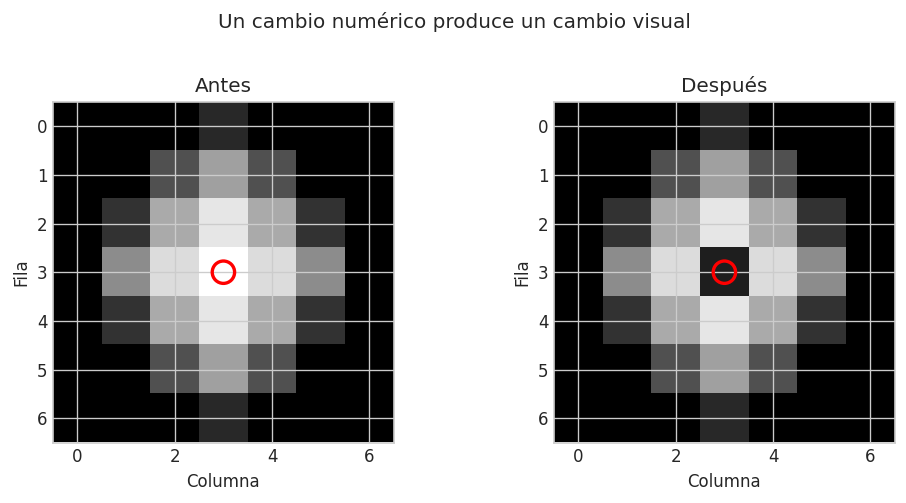

In [14]:
fila = 3
columna = 3
nueva_intensidad = 30

imagen_modificada = imagen_gris.copy()
valor_anterior = int(imagen_modificada[fila, columna])
imagen_modificada[fila, columna] = nueva_intensidad

print(f"Posición modificada: ({fila}, {columna})")
print("Valor anterior:", valor_anterior)
print("Valor nuevo:", int(imagen_modificada[fila, columna]))

fig, axes = plt.subplots(1, 2, figsize=(8.5, 4))

for ax, imagen, titulo in zip(
    axes,
    [imagen_gris, imagen_modificada],
    ["Antes", "Después"],
):
    ax.imshow(imagen, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    ax.scatter(columna, fila, s=180, facecolors="none", edgecolors="red", linewidths=2)
    ax.set_title(titulo)
    ax.set_xlabel("Columna")
    ax.set_ylabel("Fila")

fig.suptitle("Un cambio numérico produce un cambio visual", y=1.02)
plt.tight_layout()
plt.show()

El píxel central pasó de 255 a 30 y se volvió mucho más oscuro. La marca roja señala la posición, pero no forma parte de la imagen almacenada.

Para experimentar, conviene modificar una sola variable por vez: así podremos atribuir el cambio visual a una decisión concreta.

## 10. Preparación para el próximo capítulo

| Objeto | Forma habitual | Interpretación |
|---|---:|---|
| Una imagen gris | `(H, W)` | Una intensidad por píxel. |
| Una imagen RGB | `(H, W, 3)` | Tres intensidades por píxel. |
| Un lote gris | `(N, H, W)` o `(N, H, W, 1)` | Varias imágenes con un canal. |
| Un lote RGB | `(N, H, W, 3)` | Varias imágenes con tres canales. |
| Imagen gris aplanada | `(H * W,)` | Los mismos valores en una secuencia. |

En el próximo capítulo aparecerán imágenes reales de MNIST con forma 28 × 28. Allí sí cargaremos el dataset, normalizaremos sus píxeles y entrenaremos un clasificador denso. Aquí nos detuvimos en la representación de los datos para llegar a ese paso con una lectura clara de las dimensiones.

## Cierre

En este cuaderno observamos que una imagen en escala de grises puede representarse como una matriz y una imagen RGB como un array de tres dimensiones. Cada píxel ocupa una posición concreta; en color, además, contiene tres componentes.

Normalizar modifica la escala, pero no la apariencia. Reunir imágenes agrega una dimensión para el lote. Aplanar conserva todos los valores y permite alimentar una red densa, aunque la estructura espacial deja de ser explícita y la cantidad de parámetros puede crecer rápidamente.

La idea central puede resumirse así: una computadora recibe números, pero su organización también forma parte de la información.

## Para pensar

1. ¿Por qué dos matrices con las mismas intensidades pueden representar imágenes diferentes?
2. ¿Qué significa cada dimensión de un tensor con forma `(32, 64, 64, 3)`?
3. ¿Qué cambia y qué se conserva al dividir todos los píxeles por 255?
4. ¿Qué información deja de quedar explícita cuando una imagen de 28 × 28 se convierte en un vector de 784 valores?
5. ¿Por qué una capa densa crece tan rápido cuando aumenta la resolución de la imagen?